<a href="https://colab.research.google.com/github/danielandresrestrebadaleal-dev/ARC/blob/main/Jupyter_tutorial_ARC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing orbital perturbations of TESS orbit

 The goal of this tutorial is to simulate the orbit of the Transiting Exoplanet Survey Satellite (TESS) under the effect of different perturbing forces (solar radiation, gravitational forces, etc.). The simulation will be performed for approximately 8.5 years. Therefore, we aim to understand how we can minimize computational processing time by compromising some degree of accuracy in our simulation. This is achieved by ignoring the effect of each perturbing force and computing the evolution of the fractional error of the position and velocity of TESS over time. The JPL Horizons database is utilized to obtain our reference values for the position and velocity of TESS for the timespan of the simulation. By understanding which perturbing forces can be dismissed while maintaining a low fractional error, we can generalize the results of this simulation to others which have a similar orbit and thus save computational time.


In [ ]:
#Install necessary packages for Google Colab. Note: hapsira is the modern version of poliastro to handle Python 3.12
!pip install hapsira "astropy<7.0" jplephem

# Code Imports
This code utilizes several Python libraries for different functionalities:
1. poliastro: defines celestial bodies and physical constants, calculates the evolution of the orbit using Cowell Propagator, and introduces the effects of solar radiation and other forces

2. astropy: imports the JPL horizons database and handles coordinate system conversions to accurately compare the simulation results

3. numpy: performs math computations

4. matplotlib: plots evolution of fractional error for position and velocity over time in an organized graph with axes labels and legend

5. gc: clean up data



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import solar_system_ephemeris
from hapsira.bodies import Earth, Moon, Sun, Jupiter, Venus
from hapsira.twobody import Orbit
from hapsira.twobody.propagation import CowellPropagator
from hapsira.core.perturbations import third_body, radiation_pressure
from hapsira.core.propagation import func_twobody
from hapsira.ephem import build_ephem_interpolant, Ephem
from hapsira.constants import rho0_earth, H0_earth
import time
import gc
from astropy.coordinates import (
    CartesianRepresentation, CartesianDifferential, SkyCoord, ICRS, GCRS
)

# ---------------------- Simulation Configuration ----------------------
# Total simulation duration in days.
SIMULATION_DURATION_DAYS = 3050

# Environment Initialization

Ths function defines the starting time of the simulation as June 1st, 2018. It then creates an evenly-spaced position vector for each celestial body with its current position every 1 hour from the beginning to the end of the simulation. This is more effective than looking for the exact position of each celestial body for each small step in the simulation since it would significantly increase the computational time.

In [ ]:
def initialize_environment():
    """
    Set up the solar system ephemeris and build ephemeris interpolants.
    """
    # Choose ephemeris data source (JPL in this case)
    solar_system_ephemeris.set("jpl")

    # 1. Define simulation epoch as a pure Time object
    simulation_start_epoch = Time("2018-06-01T00:00:00", scale="utc", format="isot")

    # 2. Calculate the exact end Time object by adding the days directly to the Time object (NO .jd!)
    simulation_end_epoch = simulation_start_epoch + SIMULATION_DURATION_DAYS * u.day

    # Generate an array of epochs at 1-hour intervals for the interpolation
    time_span_delta = simulation_end_epoch - simulation_start_epoch
    num_steps = int(time_span_delta.to(u.hr).value) # Calculate number of steps to ensure including the end epoch
    epochs_for_interpolant = simulation_start_epoch + np.arange(num_steps + 1) * u.hr

    # 3. Build ephemeris interpolants, specifying Earth as the attractor
    moon_ephem_interp = build_ephem_interpolant(
        Moon, epochs_for_interpolant, attractor=Earth
    )
    sun_ephem_interp = build_ephem_interpolant(
        Sun, epochs_for_interpolant, attractor=Earth
    )
    jupiter_ephem_interp = build_ephem_interpolant(
        Jupiter, epochs_for_interpolant, attractor=Earth
    )
    venus_ephem_interp = build_ephem_interpolant(
        Venus, epochs_for_interpolant, attractor=Earth
    )

    # Clean up memory
    gc.collect()

    return simulation_start_epoch, moon_ephem_interp, sun_ephem_interp, jupiter_ephem_interp, venus_ephem_interp

# Setting up physical constants

This function mainly computes the required physical constants to perform the orbital simulations and converts them to the correct units

In [ ]:
# ---------------------- Physical Constants ----------------------
def define_physical_constants():
    """
    Retrieve and compute key physical constants required for the simulation.

    Returns:
        dict: A dictionary containing various physical parameters.
    """
    earth_radius_km = Earth.R.to(u.km).value
    gravitational_param = Earth.k.to(u.km**3 / u.s**2).value

    # Atmospheric drag coefficient (negligible for TESS orbit, hence set as a constant)
    drag_coefficient = 2.2

    # Area-to-mass ratio, converting from square meters/kg to square km/kg
    area_to_mass = ((3) * (u.m**2) / (350 * u.kg)).to_value(u.km**2 / u.kg)

    # Atmospheric density at Earth's surface and scale height
    surface_density = rho0_earth.to(u.kg / u.km**3).value
    scale_height = H0_earth.to(u.km).value

    # Radiation pressure coefficient and solar flux-to-speed constant ratio
    radiation_coefficient = 1.3
    solar_flux_over_c = (3.828e20) / 299792.458

    return {
        "earth_radius": earth_radius_km,
        "grav_param": gravitational_param,
        "drag_coefficient": drag_coefficient,
        "area_to_mass": area_to_mass,
        "surface_density": surface_density,
        "scale_height": scale_height,
        "radiation_coefficient": radiation_coefficient,
        "solar_flux_over_c": solar_flux_over_c,
    }

# Computing Acceleration Vector

This function creates a 3D vector representing the acceleration in the x, y, and z directions for our spacecraft. It then checks whether it is desired to calculate the effect of a perturbing force by checking the force_flags dictionary. If it is listed as "True," it calls the corresponding function from poliastro (e.g. "third_body" for celestial bodies) to add the acceleration produced by such force. In this way, we can bypass the effect of a force to analyze how accurate the simulation can still be. The function returns an acceleration vector as the addition of all the accelerations produced by the desired perturbing forces

In [ ]:
# ---------------------- Perturbation Acceleration Functions ----------------------
def compute_perturbation_acceleration(t0, state, grav_param, constants, sun_interp, moon_interp,
                                      jupiter_interp, venus_interp, force_flags):
    """
    Computes the total perturbation acceleration due to third-body effects and radiation pressure.

    Args:
        t0 (float): Initial time.
        state (ndarray): Current state vector of the spacecraft.
        grav_param (float): Gravitational parameter of the primary body.
        constants (dict): Physical constants (e.g., Earth radius, radiation coefficients).
        sun_interp: Ephemeris interpolant for the Sun.
        moon_interp: Ephemeris interpolant for the Moon.
        jupiter_interp: Ephemeris interpolant for Jupiter.
        venus_interp: Ephemeris interpolant for Venus.
        force_flags (dict): Dictionary indicating which forces to include in the simulation.

    Returns:
        ndarray: Combined acceleration vector due to all selected perturbation forces.
    """
    total_acceleration = np.zeros(3)

    # Moon's third-body effect
    if force_flags.get("Moon", True):
        total_acceleration += third_body(t0, state, grav_param,
                                         k_third=Moon.k.to(u.km**3/u.s**2).value,
                                         perturbation_body=moon_interp)
    # Sun's third-body effect (using sun_interp as the star body)
    if force_flags.get("Sun", True):
        total_acceleration += third_body(t0, state, grav_param,
                                         k_third=Sun.k.to(u.km**3/u.s**2).value,
                                         perturbation_body=sun_interp)
    # Jupiter's third-body effect
    if force_flags.get("Jupiter", True):
        total_acceleration += third_body(t0, state, grav_param,
                                         k_third=Jupiter.k.to(u.km**3/u.s**2).value,
                                         perturbation_body=jupiter_interp)
    # Venus's third-body effect
    if force_flags.get("Venus", True):
        total_acceleration += third_body(t0, state, grav_param,
                                         k_third=Venus.k.to(u.km**3/u.s**2).value,
                                         perturbation_body=venus_interp)
    # Solar radiation pressure effect
    if force_flags.get("Radiation", True):
        total_acceleration += radiation_pressure(
            t0, state, grav_param,
            constants["earth_radius"],
            constants["radiation_coefficient"],
            constants["area_to_mass"],
            constants["solar_flux_over_c"],
            sun_interp
        )
    return total_acceleration

# Computing the derivative of the state vector

In order to use the Cowell Propagator from poliastro, this function computes how fast the position and velocity of the spacecraft is changing at a specific point in time. It calculates the velocity and acceleration vector based on a 2-body Keplerian motion model between the Earth and the spacecraft. Then, it adds all the third-body effects to this vector to obtain a final vector describing how both the position and velocity are changing through time at that instant.

In [ ]:
def perturbation_derivatives(t0, state, grav_param, constants, sun_interp, moon_interp,
                             jupiter_interp, venus_interp, force_flags):
    """
    Computes the time derivatives of the state vector including both Keplerian and perturbation accelerations.

    Args:
        t0 (float): Initial time.
        state (ndarray): Current state vector.
        grav_param (float): Gravitational parameter for the primary body.
        constants (dict): Dictionary of physical constants.
        sun_interp, moon_interp, jupiter_interp, venus_interp: Ephemeris interpolants.
        force_flags (dict): Flags indicating which perturbing forces are active.

    Returns:
        ndarray: Time derivative of the state vector.
    """
    # Two-body (Keplerian) derivative
    keplerian_deriv = func_twobody(t0, state, grav_param)

    # Compute total perturbation acceleration.
    accel_perturb = compute_perturbation_acceleration(
        t0, state, grav_param, constants, sun_interp, moon_interp, jupiter_interp, venus_interp, force_flags
    )

    # Append the perturbation acceleration (affecting velocity components) to the Keplerian derivative.
    return keplerian_deriv + np.array([0, 0, 0, accel_perturb[0], accel_perturb[1], accel_perturb[2]])

# Initializing the orbit

This function defines the Orbit object needed to start the simulation. To do so, it extracts the the state vector of TESS at the starting time of our simulation from the JPL Horizons database. It performs some necessary unit conversions and translates the vector from ICRS (Sun-centered) to GCRS (Earth-centered) coordinate system, as poliastro uses GCRS as default for orbit propagations.

In [ ]:
# ---------------------- Orbit Initialization ----------------------
def initialize_orbit(simulation_epoch):
    """
    Create the initial orbit state from spacecraft ephemeris data (using TESS as reference).
    The state vector is transformed from the ICRS frame to the GCRS frame.

    Args:
        simulation_epoch (Time): The epoch of the simulation start.

    Returns:
        Orbit: The initial Orbit object.
    """
    # Retrieve TESS ephemeris data from Horizons system.
    tess_ephem = Ephem.from_horizons("TESS", epochs=simulation_epoch)

    # Get position and velocity vectors in km and km/s respectively.
    position_icrf = np.array(tess_ephem.rv()[0].to(u.km).value).reshape(-1)
    velocity_icrf = np.array(tess_ephem.rv()[1].to(u.km / u.s).value).reshape(-1)

    # Create initial orbit in ICRF frame from position and velocity.
    orbit_icrf = Orbit.from_vectors(Earth, position_icrf * u.km, velocity_icrf * (u.km / u.s), epoch=simulation_epoch)

    # Extract ICRF vectors
    r_icrf, v_icrf = orbit_icrf.rv()

    # Transform state vector from ICRS/ICRF to the GCRS frame.
    cart_representation = CartesianRepresentation(*r_icrf)
    cart_differentials = CartesianDifferential(*v_icrf)
    icrs_coord = SkyCoord(cart_representation.with_differentials(cart_differentials),
                           frame=ICRS, obstime=simulation_epoch)
    gcrs_coord = icrs_coord.transform_to(GCRS(obstime=simulation_epoch))

    # Retrieve transformed position and velocity components.
    r_gcrs = gcrs_coord.data.represent_as(CartesianRepresentation).xyz
    v_gcrs = gcrs_coord.data.differentials["s"].d_xyz

    # Clean up temporary variables.
    del cart_representation, cart_differentials, icrs_coord, gcrs_coord
    gc.collect()

    return Orbit.from_vectors(Earth, r_gcrs, v_gcrs, epoch=simulation_epoch)

# Orbit propagation

This function simply propagates the starting orbit using poliastro's Cowell Propagator over the specified time interval. It returns the final orbit object after the simulation, from which we can extract the state vector. In principle, this function is called for each time step during the simulation to obtain a continuous evolution of the position and velocity of the spacecraft

In [ ]:
# ---------------------- Orbit Propagation & Data Processing ----------------------
def propagate_orbit(orbit_obj, time_interval, perturbation_function):
    """
    Propagate the orbit over a specified time interval using the Cowell propagator.

    Args:
        orbit_obj (Orbit): The initial Orbit object.
        time_interval (Quantity): Duration over which to propagate.
        perturbation_function (function): Function to compute perturbations.

    Returns:
        Orbit: Final orbit after propagation.
    """
    propagated_orbit = orbit_obj.propagate(
        time_interval, method=CowellPropagator(rtol=3e-14, f=perturbation_function)
    )
    gc.collect()
    return propagated_orbit

# Creating evenly-spaced time intervals

This function creates epoch objects which are evenly spaced. The number of intervals is user-defined and can affect the how precise our simulation is. A good value should be chosen so that we can have enough precision while still running the program in a reasonable amount of time. Thus, 100 intervals were chosen.

In [ ]:
def create_simulation_epochs(start_epoch, end_epoch, num_intervals):
    """
    Generate an array of epochs spanning from the start to the end epoch.
    """
    # Safely convert the TimeDelta into raw seconds
    total_seconds = (end_epoch - start_epoch).to(u.s).value

    # Generate the checkpoints and add them back to the start time
    epochs = start_epoch + np.linspace(0, total_seconds, num_intervals + 1) * u.s

    gc.collect()
    return epochs

# Extracting data for error analysis

This function calls the Cowell Propagator for each time interval to obtain the Orbit object for each time step. Then, it extracts the position and velocity vector from each object. These values are converted from GCRS to the ICRS coordinate system for comparison with the JPL Horizons database

In [ ]:
def simulate_spacecraft_trajectory(orbit_obj, perturbation_function, epoch_array):
    """
    Propagate the spacecraft orbit for each epoch in the provided array and convert the results
    to ICRS frame state vectors.

    Args:
        orbit_obj (Orbit): Initial orbit.
        perturbation_function (function): Function to compute perturbation accelerations.
        epoch_array (Quantity): Array of epochs at which to propagate the orbit.

    Returns:
        tuple: (r_state, v_state) state arrays in the ICRS frame.
    """
    start_time = time.perf_counter()
    propagated_orbits = [
        orbit_obj.propagate(ep, method=CowellPropagator(rtol=3e-14, f=perturbation_function))
        for ep in epoch_array
    ]
    end_time = time.perf_counter()
    print("Propagation time: {:.3f} seconds".format(end_time - start_time))

    positions, velocities, epochs_list = [], [], []
    for orbit_instance in propagated_orbits:
        positions.append(orbit_instance.r)
        velocities.append(orbit_instance.v)
        epochs_list.append(orbit_instance.epoch)

    # Convert lists to numpy arrays
    pos_array = np.array(positions)
    vel_array = np.array(velocities)
    epochs_array = Time(epochs_list)

    # Convert coordinates from GCRS to ICRS for output and analysis.
    conversion_start = time.perf_counter()
    sky_coordinates = SkyCoord(
        CartesianRepresentation(
            pos_array[:, 0] * u.km,
            pos_array[:, 1] * u.km,
            pos_array[:, 2] * u.km,
            differentials=CartesianDifferential(
                vel_array[:, 0] * (u.km / u.s),
                vel_array[:, 1] * (u.km / u.s),
                vel_array[:, 2] * (u.km / u.s)
            )
        ),
        frame=GCRS,
        obstime=epochs_array
    )
    icrs_coordinates = sky_coordinates.transform_to(ICRS)
    r_state = icrs_coordinates.cartesian.xyz.T.value
    v_state = icrs_coordinates.cartesian.differentials["s"].d_xyz.T.value

    # Clean up and free memory.
    del positions, velocities, pos_array, vel_array, epochs_list, epochs_array, sky_coordinates, icrs_coordinates
    gc.collect()

    conversion_end = time.perf_counter()
    print("Coordinate conversion time: {:.3f} seconds".format(conversion_end - conversion_start))
    return r_state, v_state

# Retrieving TESS data from JPL Horizons

At each time step, this function retrieves the position and velocity vectors from JPL Horizons for TESS

In [ ]:
def retrieve_actual_spacecraft_data(epoch_array, num_intervals):
    """
    Obtain reference spacecraft data from Horizons (using TESS as reference) for error comparison.

    Args:
        epoch_array (Quantity): Array of simulation epochs.
        num_intervals (int): Number of intervals (subdivisions used during simulation).

    Returns:
        tuple: (r_actual, v_actual) state arrays from reference data.
    """
    tess_ephem_list = [Ephem.from_horizons("TESS", epochs=ep) for ep in epoch_array]
    actual_positions = np.array([ephem.rv()[0].to(u.km).value for ephem in tess_ephem_list])
    actual_velocities = np.array([ephem.rv()[1].to(u.km / u.s).value for ephem in tess_ephem_list])

    # Ensure that the arrays have the expected dimensions.
    r_actual = actual_positions.reshape(num_intervals + 1, 3)
    v_actual = actual_velocities.reshape(num_intervals + 1, 3)
    del tess_ephem_list
    gc.collect()
    return r_actual, v_actual

# Computing and plotting fractional error over time

These functions calculate and plot the fractional error as a function of time for the duration of the simulation. The fractional error for the position and velocity vectors are computed as the difference between the Euclidean norm between the simulation vector and JPL Horizons vector dividided by the JPL Horizons vector. This is done for each time step using vectorized operations with the help of numpy. The results are plotted in two different figures: one for the position and one for the velocity vector

In [ ]:
# ---------------------- Error Analysis ----------------------
def calculate_fractional_errors(simulated_positions, reference_positions, simulated_velocities, reference_velocities):
    """
    Calculate the fractional errors between simulated and reference position and velocity vectors.

    Args:
        simulated_positions (ndarray): Simulated positions.
        reference_positions (ndarray): Reference positions.
        simulated_velocities (ndarray): Simulated velocities.
        reference_velocities (ndarray): Reference velocities.

    Returns:
        tuple: Fractional errors for positions and velocities.
    """
    # Position error calculations
    position_error_norm = np.linalg.norm(simulated_positions - reference_positions, axis=1)
    reference_position_norm = np.linalg.norm(reference_positions, axis=1)
    fractional_error_position = position_error_norm / reference_position_norm

    # Velocity error calculations
    velocity_error_norm = np.linalg.norm(simulated_velocities - reference_velocities, axis=1)
    reference_velocity_norm = np.linalg.norm(reference_velocities, axis=1)
    fractional_error_velocity = velocity_error_norm / reference_velocity_norm

    return fractional_error_position, fractional_error_velocity

# ---------------------- Plotting Functions ----------------------
def plot_fractional_errors(time_years, position_errors_dict, velocity_errors_dict):
    """
    Plot and save the fractional error comparisons for positions and velocities.

    Args:
        time_years (ndarray): Time axis in years.
        position_errors_dict (dict): Dictionary of position error arrays keyed by simulation case label.
        velocity_errors_dict (dict): Dictionary of velocity error arrays keyed by simulation case label.
    """
    # Plot position fractional errors.
    fig_pos, ax_pos = plt.subplots(figsize=(10, 6))
    for label, error_array in position_errors_dict.items():
        ax_pos.plot(time_years, error_array, 'o-', label=label)
    ax_pos.set_title('Fractional Error in Position Magnitude')
    ax_pos.set_xlabel('Time Since Start (years)')
    ax_pos.set_ylabel('Fractional Error')
    ax_pos.legend()
    fig_pos.savefig("position_magnitude_error.png", dpi=130)

    # Plot velocity fractional errors.
    fig_vel, ax_vel = plt.subplots(figsize=(10, 6))
    for label, error_array in velocity_errors_dict.items():
        ax_vel.plot(time_years, error_array, 'o-', label=label)
    ax_vel.set_title('Fractional Error in Velocity Magnitude')
    ax_vel.set_xlabel('Time Since Start (years)')
    ax_vel.set_ylabel('Fractional Error')
    ax_vel.legend()
    fig_vel.savefig("velocity_magnitude_error.png", dpi=130)

    plt.show()

# Main program function

This is the main function of the program that handles all other functions. Its main purpose is to update the force_flags dictionary each time with a new force turned "off" and plot the results for that corresponding case

In [ ]:
# ---------------------- Main Simulation Routine ----------------------
def main_simulation():
    # Initialize simulation environment and physical constants.
    sim_epoch, moon_interp, sun_interp, jupiter_interp, venus_interp = initialize_environment()
    physical_constants = define_physical_constants()

    # Initialize the spacecraft orbit using reference (TESS) data.
    initial_orbit = initialize_orbit(sim_epoch)

    # Define the number of intervals for simulation sampling.
    NUM_INTERVALS = 100

    # Propagate orbit without any modifications to define final simulation end epoch.
    final_orbit = propagate_orbit(
        initial_orbit,
        SIMULATION_DURATION_DAYS * u.day,
        lambda t0, state, k: perturbation_derivatives(
            t0, state, k, physical_constants, sun_interp, moon_interp, jupiter_interp,
            venus_interp, {"Moon": True, "Sun": True, "Jupiter": True, "Venus": True, "Radiation": True}
        )
    )

    # Generate an array of epochs between the start and final orbit epochs.
    simulation_epochs = create_simulation_epochs(initial_orbit.epoch, final_orbit.epoch, NUM_INTERVALS)

    # Retrieve reference spacecraft data for error analysis.
    reference_positions, reference_velocities = retrieve_actual_spacecraft_data(simulation_epochs, NUM_INTERVALS)

    # Define base force flags and simulation cases (each turning off one perturbation).
    base_force_flags = {
        "Moon": True, "Sun": True, "Jupiter": True, "Venus": True, "Radiation": True
    }
    simulation_cases = {
        "Without Moon": {**base_force_flags, "Moon": False},
        "Without Sun": {**base_force_flags, "Sun": False},
        "Without Jupiter": {**base_force_flags, "Jupiter": False},
        "Without Venus": {**base_force_flags, "Venus": False},
        "Without Radiation": {**base_force_flags, "Radiation": False},
        "All Forces": base_force_flags.copy()
    }

    # Dictionaries to hold the fractional errors for each simulation case.
    pos_errors_dict = {}
    vel_errors_dict = {}
    # Convert epochs difference to years for x-axis plotting.
    time_axis_years = (simulation_epochs - simulation_epochs[0]).sec / (3600 * 24 * 365.25)

    # Execute simulation for each force configuration.
    for case_label, force_config in simulation_cases.items():
        # Define the perturbation function using current force configuration.
        perturbation_function = lambda t0, state, k, flags=force_config: perturbation_derivatives(
            t0, state, k, physical_constants, sun_interp, moon_interp, jupiter_interp, venus_interp, flags
        )
        simulated_positions, simulated_velocities = simulate_spacecraft_trajectory(initial_orbit, perturbation_function, simulation_epochs)

        # Compute fractional errors between simulation and reference data.
        frac_err_pos, frac_err_vel = calculate_fractional_errors(simulated_positions, reference_positions,
                                                                  simulated_velocities, reference_velocities)
        pos_errors_dict[case_label] = frac_err_pos
        vel_errors_dict[case_label] = frac_err_vel

    # Plot and save error comparisons.
    plot_fractional_errors(time_axis_years, pos_errors_dict, vel_errors_dict)
    gc.collect()

# Execute the simulation only if this script is run directly.
if __name__ == "__main__":
    main_simulation()

The following figures are obtained from this code:

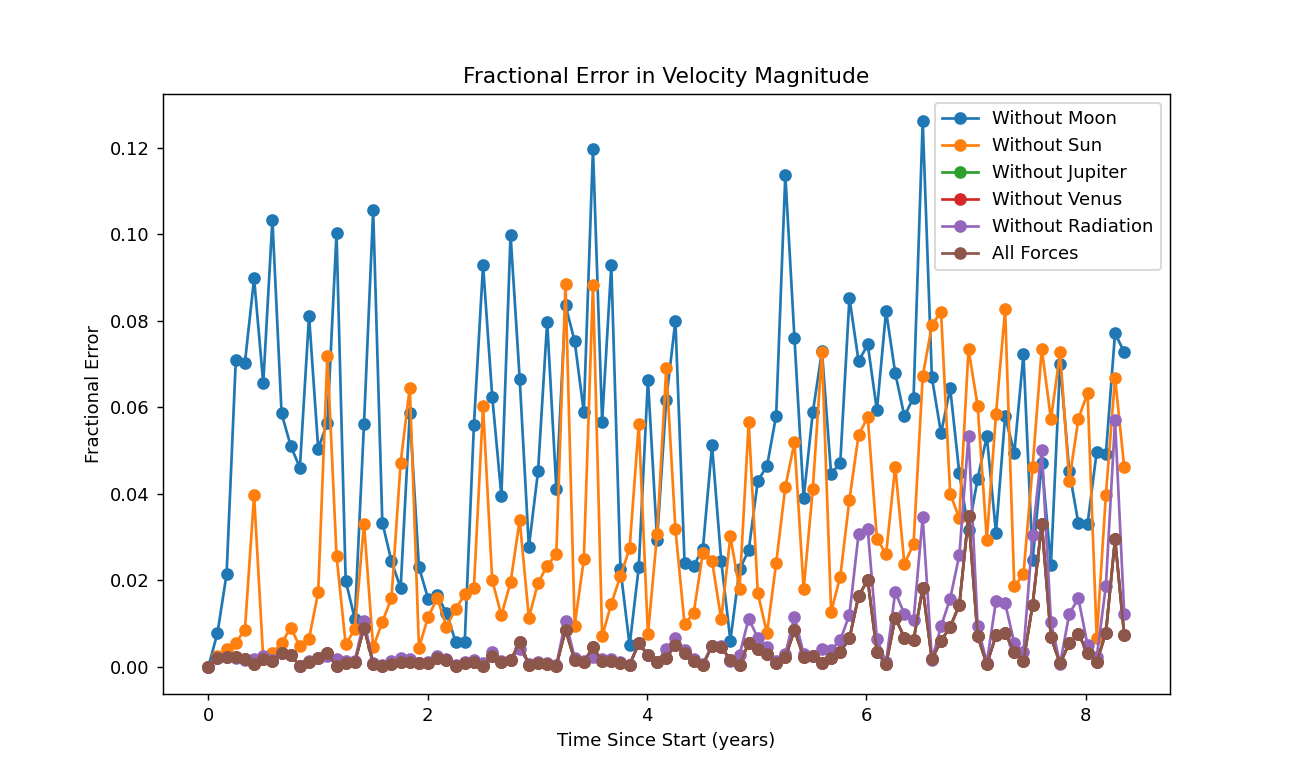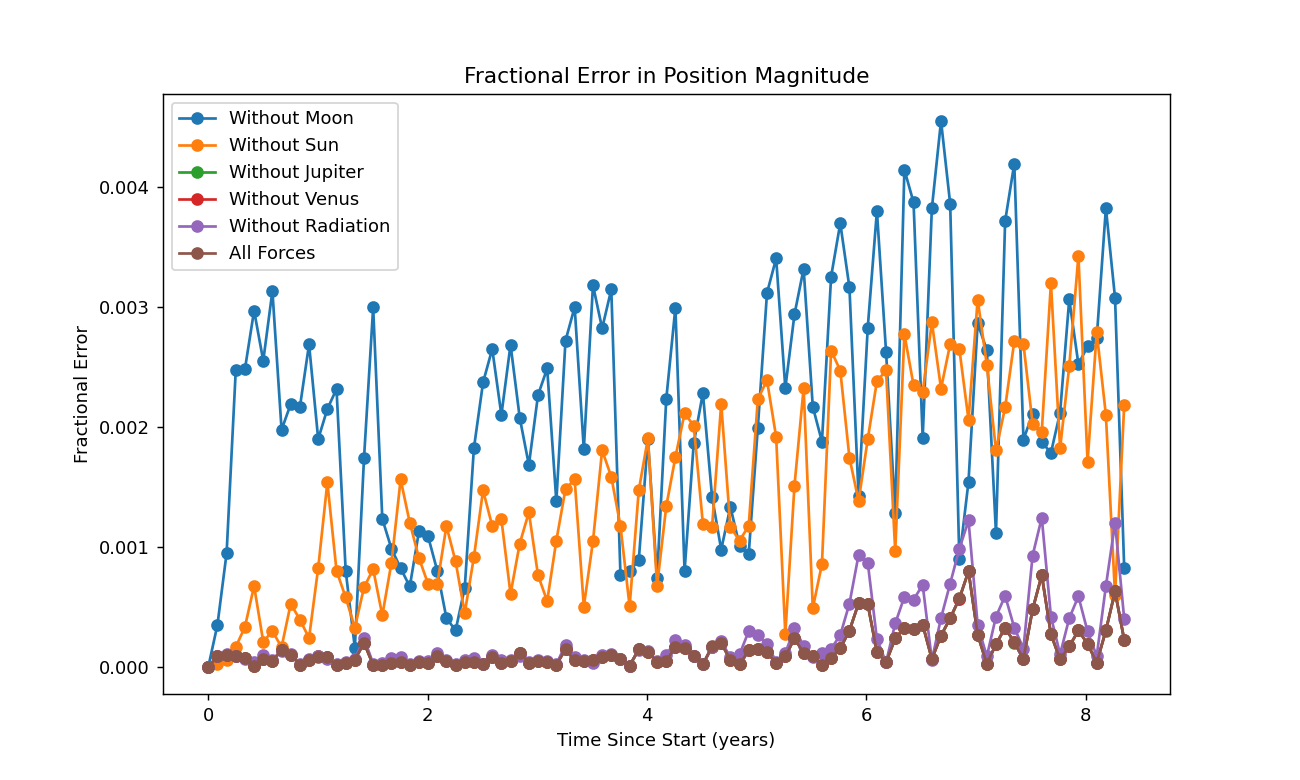

#

# Results and Conclusions

Both graphs show the need to include the third-body effects from the Moon and the Sun to obtain accurate simulations. The fractional error for the magnitude of both the position and the velocity spikes at a very early stage of the simulation when the gravitational forces from these bodies is ignored. The solar radiation force becomes more relevant at around 6 years after the beginning of the simulation, where it starts to clearly diverge from the "All forces" case. In contrast, removing the influence of secondary celestial bodies, such as Jupiter and Venus, on the orbit of the simulated spacecraft shows no clear sign of loss of accuracy. Based on these results, it can be concluded that when simulating the orbit of a spacecraft on High-Earth Orbit (HEO), such as TESS, it is crucial to include the gravitational effects of primary celestial bodies like the Moon and the Sun while the influence from planets like Jupiter and Venus can be removed, saving computational time while not compromising a significant loss of accuracy

